In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("../Filtered Data with Subtypes Again.xlsx")

In [4]:
df.replace('Single Issue', 'Single Issue Charity', inplace=True)

# List of metrics we want to analyze
metrics = ["Accounts", "Contributions", "Grants", "Assets"]

group_totals = (
    df
    .groupby(["Year", "Type", "subtype"], as_index=False)[metrics]
    .sum()
)


group_totals = group_totals.sort_values(["Type", "subtype", "Year"])

group_totals["group_year_diff"] = (
    group_totals
    .groupby(["Type", "subtype"])["Year"]
    .diff()
)

for m in metrics:
    group_totals[f"group_{m.lower()}_growth"] = (
        group_totals
        .groupby(["Type", "subtype"])[m]
        .pct_change()
    )

    # Ignore non-consecutive group years
    group_totals.loc[
        group_totals["group_year_diff"] != 1,
        f"group_{m.lower()}_growth"
    ] = None

In [5]:
df = df.merge(
    group_totals[
        ["Year", "Type", "subtype"] +
        [f"group_{m.lower()}_growth" for m in metrics]
    ],
    on=["Year", "Type", "subtype"],
    how="left"
)

df = df.sort_values(["ein", "Year"])

df["ein_year_diff"] = df.groupby("ein")["Year"].diff()

for m in metrics:
    prev_actual = df.groupby("ein")[m].shift(1)

    df[f"predicted_{m.lower()}"] = prev_actual * (
        1 + df[f"group_{m.lower()}_growth"]
    )

    # Remove predictions when EIN years are not consecutive
    df.loc[df["ein_year_diff"] != 1, f"predicted_{m.lower()}"] = None

In [6]:
pred_cols = ["predicted_accounts", "predicted_contributions",  "predicted_grants", "predicted_assets"]

for col in pred_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

In [7]:
def relative_grouped_error(actual_col, predicted_col):
    valid_rows = group[group[predicted_col].notna()&group[actual_col].notna()&(group[actual_col] !=0)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
    ME =(abs((total_actual - total_predicted)/total_actual)).median()
    return ME

RE_account_by_year = []
RE_contributions_by_year = []
RE_grants_by_year = []
RE_assets_by_year = []

grouped = df.groupby("Year")
for year, group in grouped:
    RE_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    RE_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    RE_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    RE_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

print(RE_account_by_year)


[nan, 0.1454492014836688, 0.07800074170314583, 0.05292347693035355, 0.06811422984478765, 0.052900568290171396, 0.055314062160400024, 0.08391781751888851, 0.05529869750354847, 0.045596362418072335, 0.06965015506796907, 0.060725124647734705, 0.07957593562396229, 0.07196718725351008, 0.05828066725897358, 0.06775498673911409, 0.08271580212297214, 0.4681218399309409]


C:\Users\marsh\AppData\Local\Temp\ipykernel_4052\1353895012.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)


In [8]:
def relative_error(actual_col, predicted_col):
    valid_rows = df[df[predicted_col].notna()&df[actual_col].notna()&(df[actual_col] !=0)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
    ME =(abs((total_actual - total_predicted)/total_actual)).median()
    return ME

relative_error("Accounts", "predicted_accounts")

0.07260050159264814

In [9]:
community_account_by_year = []
community_contributions_by_year = []
community_grants_by_year = []
community_assets_by_year = []

national_account_by_year = []
national_contributions_by_year = []
national_grants_by_year = []
national_assets_by_year = []

single_account_by_year = []
single_contributions_by_year = []
single_grants_by_year = []
single_assets_by_year = []

community_df = df[df["Type"] == "Community Foundation"]
cgroups = community_df.groupby("subtype")
for subtype, group in cgroups:
    community_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    community_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    community_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    community_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

national_df = df[df["Type"] == "National"]
ngroups = national_df.groupby("subtype")
for subtype, group in ngroups:
    national_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    national_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    national_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    national_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

single_df = df[df["Type"] == "Single Issue Charity"]
sgroups = single_df.groupby("subtype")
for subtype, group in sgroups:
    single_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    single_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    single_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    single_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

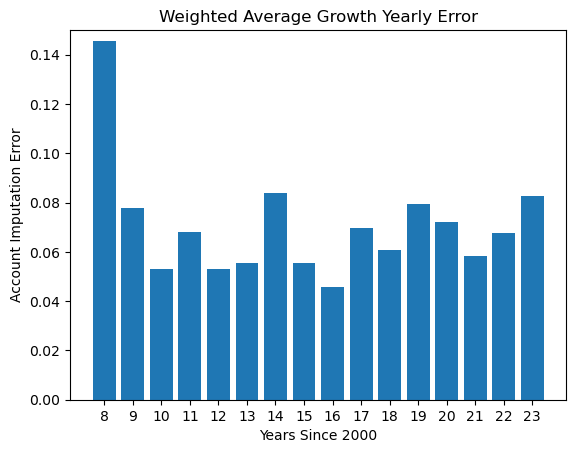

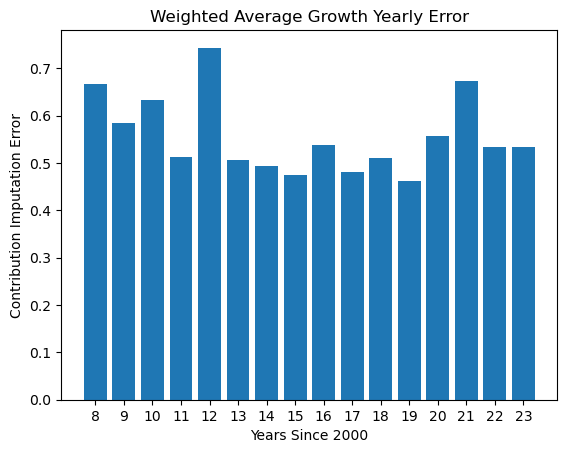

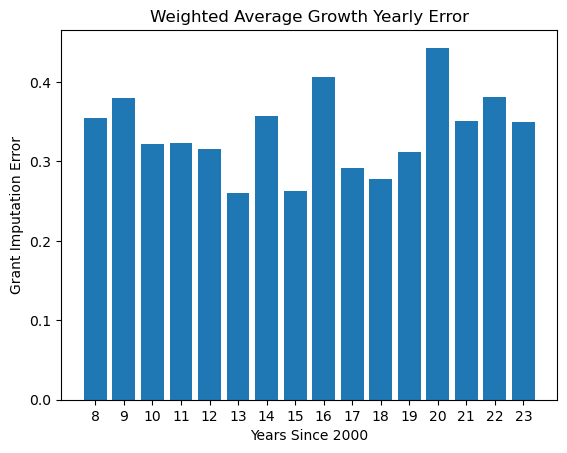

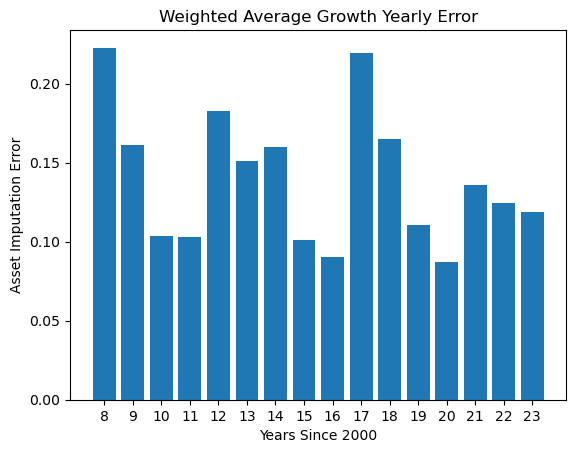

In [10]:
account_error_by_year = RE_account_by_year[1:-1]
contribution_error_by_year = RE_contributions_by_year[1:-1]
grant_error_by_year = RE_grants_by_year[1:-1]
asset_error_by_year = RE_assets_by_year[1:-1]

Year = range(7, 23)

plt.bar(Year, account_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Account Imputation Error")
plt.title("Weighted Average Growth Yearly Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.ylim(0, .15)
plt.show()

plt.bar(Year, contribution_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Contribution Imputation Error")
plt.title("Weighted Average Growth Yearly Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, grant_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Grant Imputation Error")
plt.title("Weighted Average Growth Yearly Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, asset_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Asset Imputation Error")
plt.title("Weighted Average Growth Yearly Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

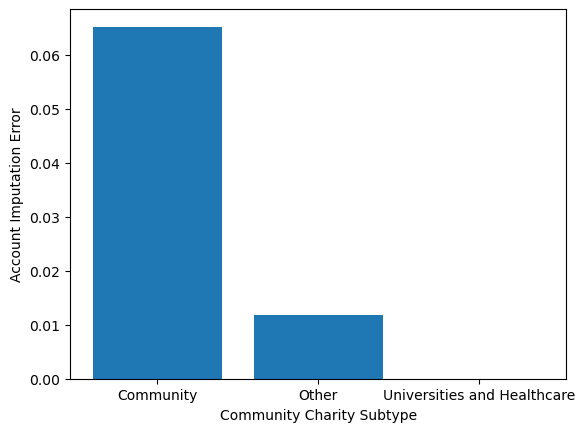

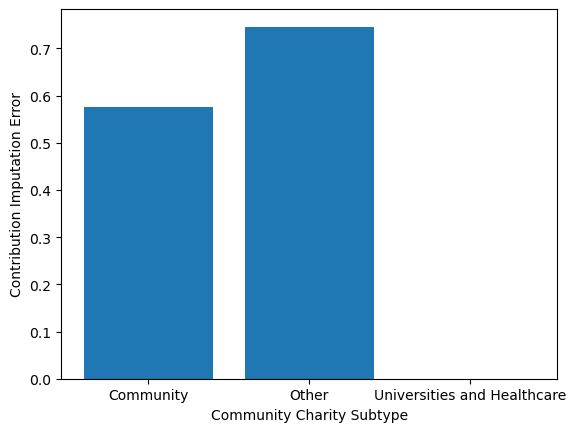

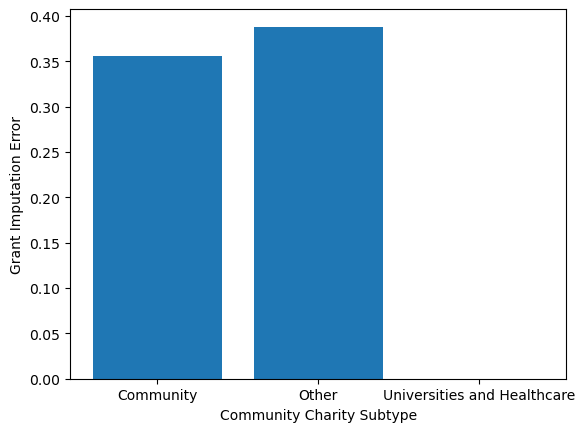

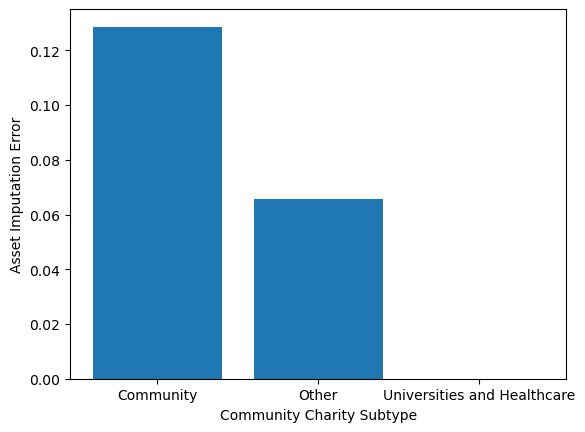

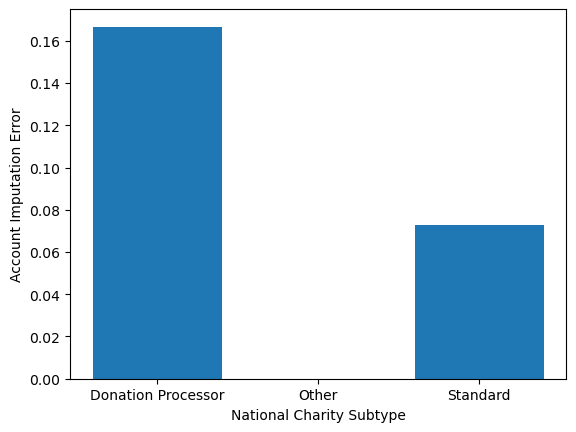

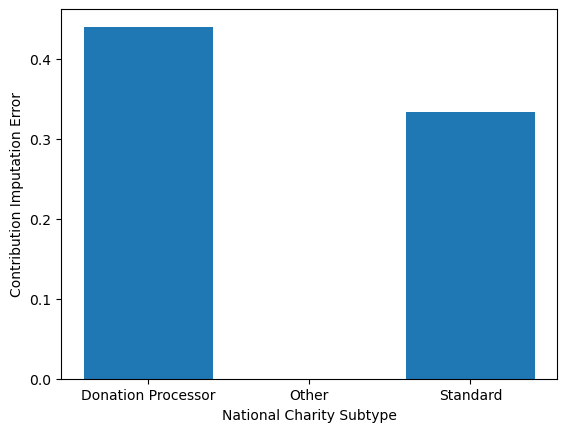

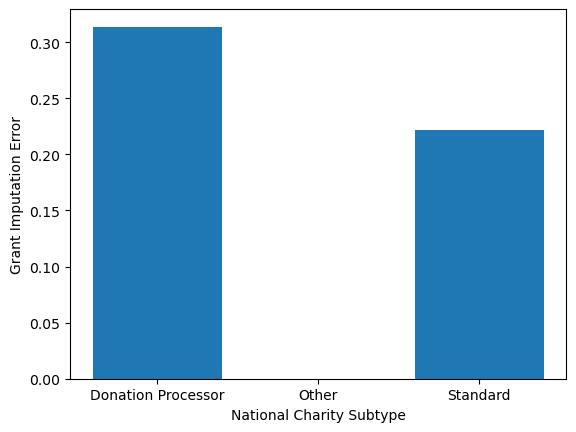

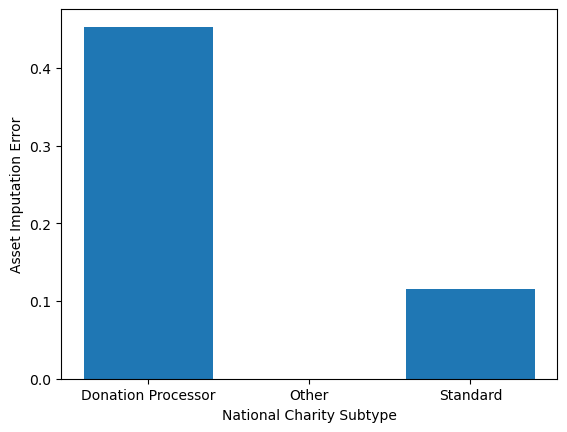

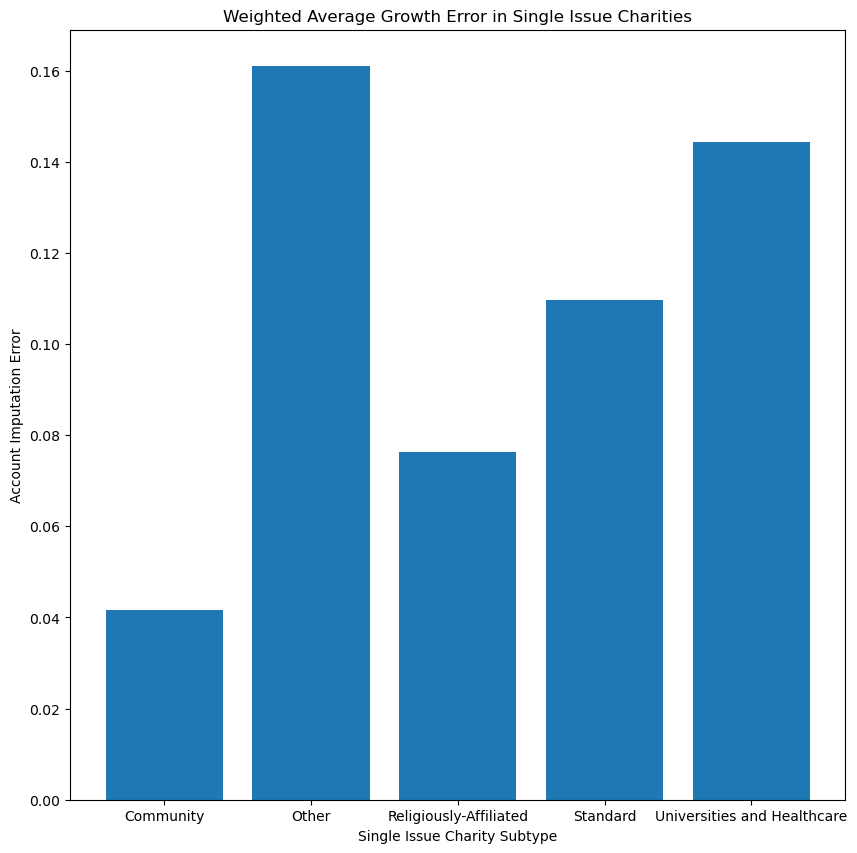

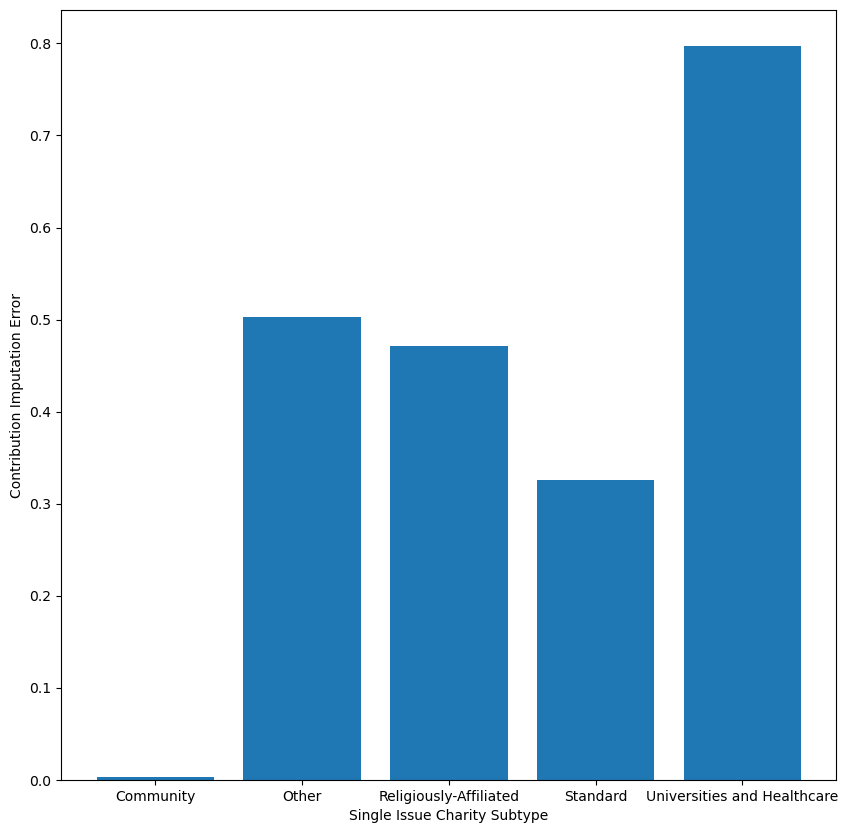

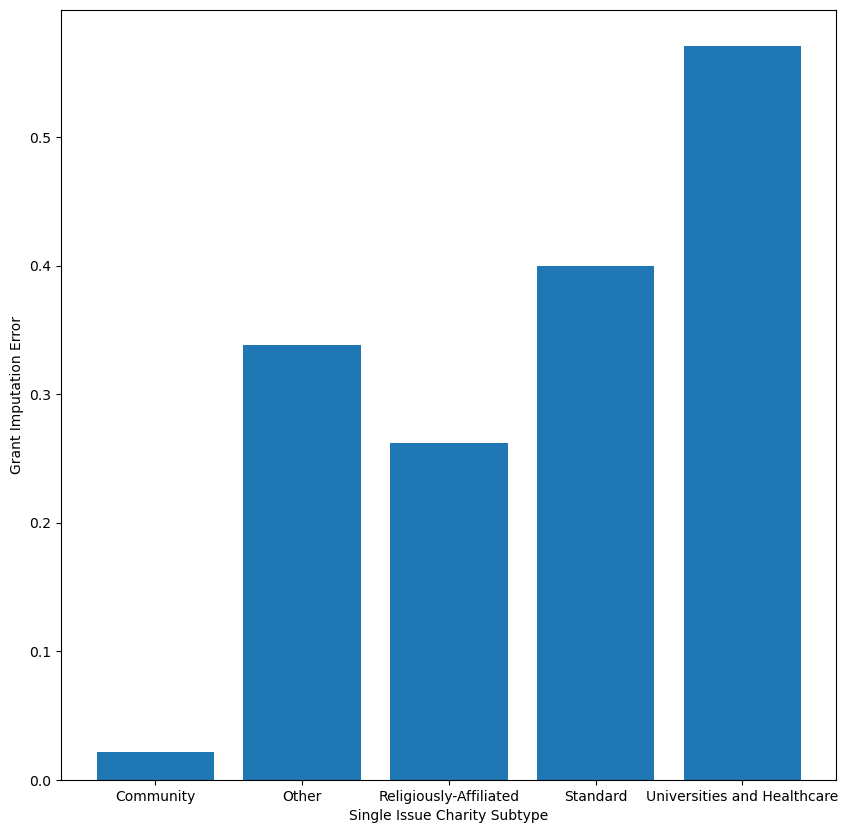

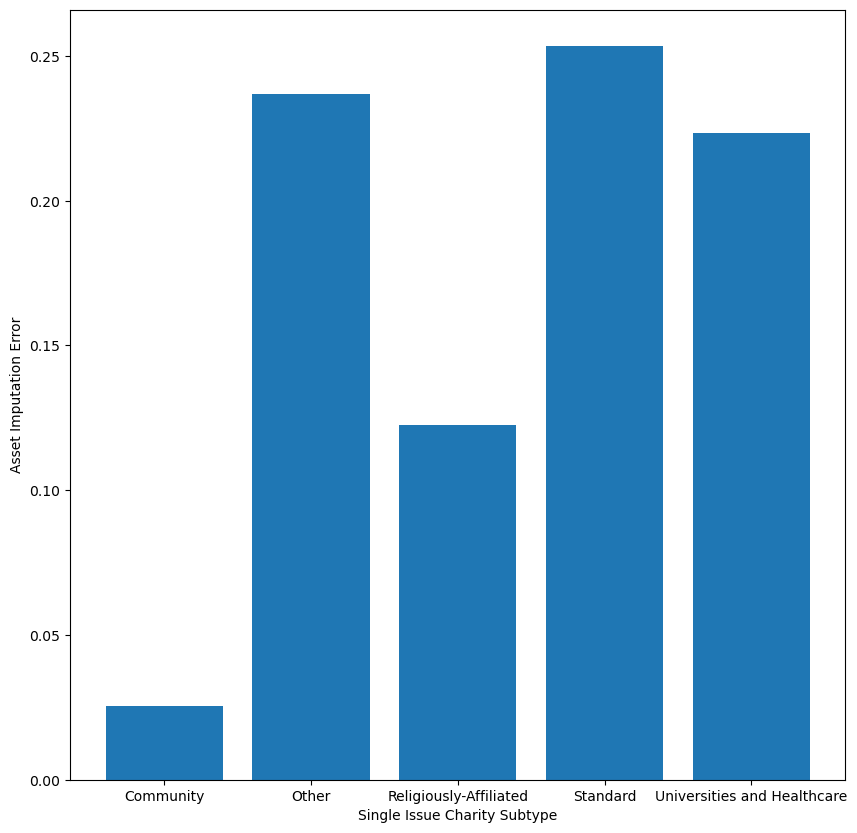

In [11]:
plt.bar(list(cgroups.groups.keys()), community_account_by_year)
plt.xlabel("Community Charity Subtype")
plt.ylabel("Account Imputation Error")
plt.show()

plt.bar(list(cgroups.groups.keys()), community_contributions_by_year)
plt.xlabel("Community Charity Subtype")
plt.ylabel("Contribution Imputation Error")
plt.show()

plt.bar(list(cgroups.groups.keys()), community_grants_by_year)
plt.xlabel("Community Charity Subtype")
plt.ylabel("Grant Imputation Error")
plt.show()

plt.bar(list(cgroups.groups.keys()), community_assets_by_year)
plt.xlabel("Community Charity Subtype")
plt.ylabel("Asset Imputation Error")
plt.show()

plt.bar(list(ngroups.groups.keys()), national_account_by_year)
plt.xlabel("National Charity Subtype")
plt.ylabel("Account Imputation Error")
plt.show()

plt.bar(list(ngroups.groups.keys()), national_contributions_by_year)
plt.xlabel("National Charity Subtype")
plt.ylabel("Contribution Imputation Error")
plt.show()

plt.bar(list(ngroups.groups.keys()), national_grants_by_year)
plt.xlabel("National Charity Subtype")
plt.ylabel("Grant Imputation Error")
plt.show()

plt.bar(list(ngroups.groups.keys()), national_assets_by_year)
plt.xlabel("National Charity Subtype")
plt.ylabel("Asset Imputation Error")
plt.show()

plt.figure(figsize=(10,10))
plt.bar(list(sgroups.groups.keys()), single_account_by_year)
plt.xlabel("Single Issue Charity Subtype")
plt.ylabel("Account Imputation Error")
plt.title("Weighted Average Growth Error in Single Issue Charities")
plt.show()

plt.figure(figsize=(10,10))
plt.bar(list(sgroups.groups.keys()), single_contributions_by_year)
plt.xlabel("Single Issue Charity Subtype")
plt.ylabel("Contribution Imputation Error")
plt.show()

plt.figure(figsize=(10,10))
plt.bar(list(sgroups.groups.keys()), single_grants_by_year)
plt.xlabel("Single Issue Charity Subtype")
plt.ylabel("Grant Imputation Error")
plt.show()

plt.figure(figsize=(10,10))
plt.bar(list(sgroups.groups.keys()), single_assets_by_year)
plt.xlabel("Single Issue Charity Subtype")
plt.ylabel("Asset Imputation Error")
plt.show()

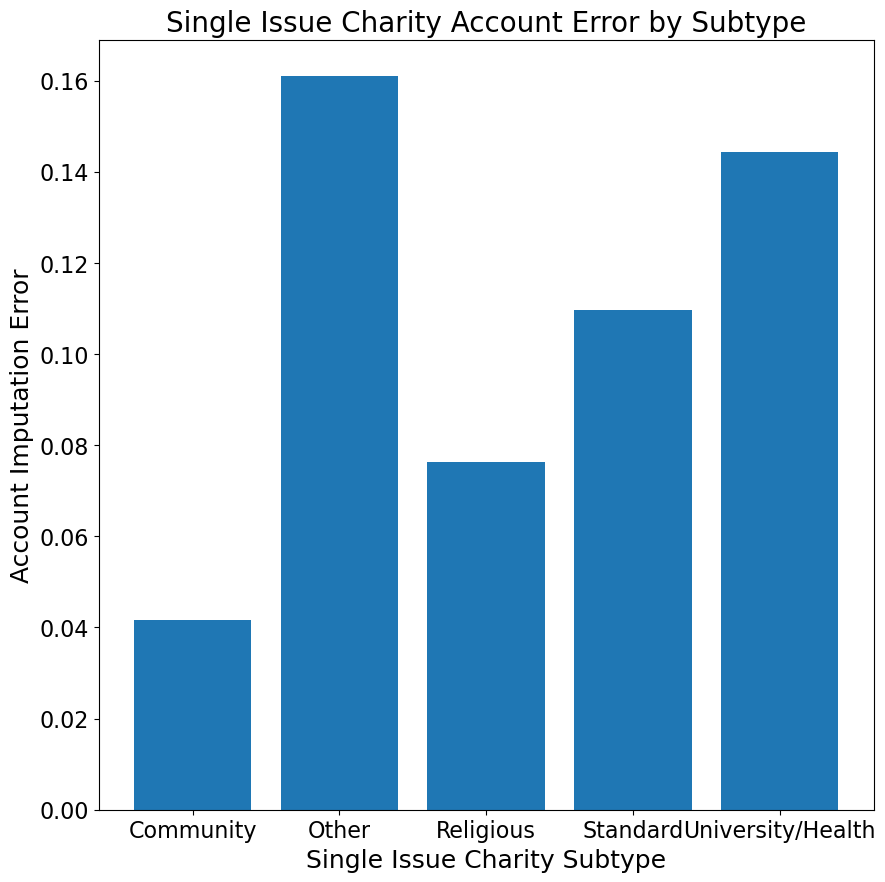

In [15]:
labels = ['Community', 'Other', 'Religious', 'Standard', 'University/Health']
plt.figure(figsize=(10,10))
plt.bar(labels, single_account_by_year)
plt.title("Single Issue Charity Account Error by Subtype", fontsize=20)
plt.xlabel("Single Issue Charity Subtype", fontsize=18)
plt.ylabel("Account Imputation Error", fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()